In [2]:
import Distributions
import Random
include("spectrum_truncation_analysis.jl")
#include("liouville_space.jl")

Random.seed!(1234)
n = 5                  # number of system qubits
J = rand(Distributions.Uniform(1/4, 3/4), n-1)
gammas = fill(0.05, n)     # uniform amplitude-damping rate on every qubit
t = 3.0                    # total evolution time
k = 8                # Trotter step counts to compare (k_i, k_j)
cutoff = 1e-10
maxdim = 250
order = 1
dissipation = true
lsites = liouville_siteinds(n)

result = track_Fii_spectrum(
    n, J, gammas, t, k, lsites, cutoff, maxdim;
    order, dissipation)

(layer = [1, 2, 3, 4, 5, 6, 7, 8], bond_dim = [16, 222, 244, 250, 250, 250, 250, 250], spectrum = [[29.18592714694139, 0.1805306918559061, 0.18051757167276591, 0.06873517744770599, 0.06707815312589115, 0.05291341519603922, 0.05291339108329775, 0.0529129014035207, 0.052912861327671736, 0.05289400531746742, 0.05289373445835248, 0.05289360318793073, 0.052893321059424986, 2.5217161293744533e-10, 2.2322160166855167e-11, 9.354648912942866e-12], [26.695482891958616, 0.3420029215275012, 0.3390106488969728, 0.23917695172174389, 0.2274385571033156, 0.12834206831148195, 0.12834199783208064, 0.12727757189275676, 0.12727750841410954, 0.12610307234356372  …  2.3475448976739986e-6, 2.3452833524578115e-6, 1.8803323562466533e-6, 1.8799002246991797e-6, 1.771844696738094e-6, 1.58338407915698e-6, 6.536682774902223e-7, 6.536330256449646e-7, 5.358036102848737e-7, 5.353232817323358e-7], [24.472421334170917, 0.41923713576468097, 0.39645518763620285, 0.38846157221549377, 0.3869787366144424, 0.2053350853510421,

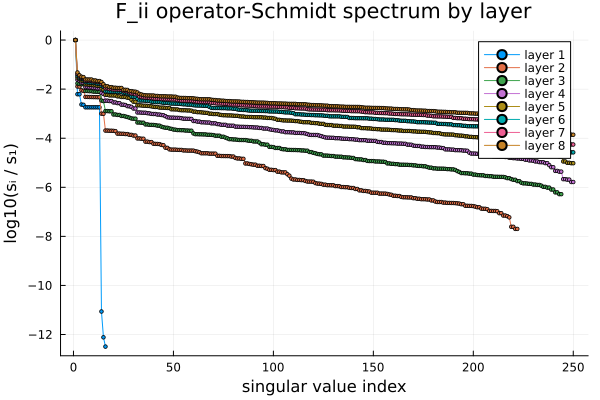

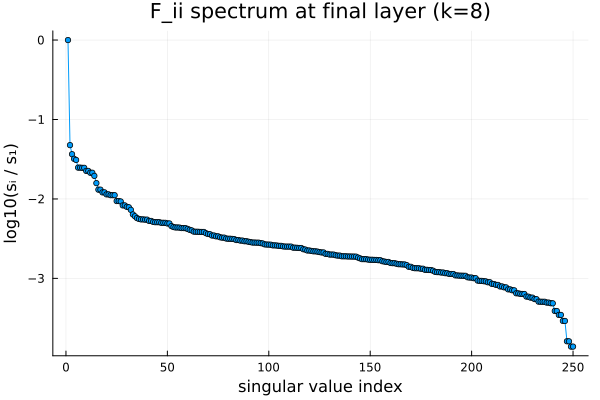

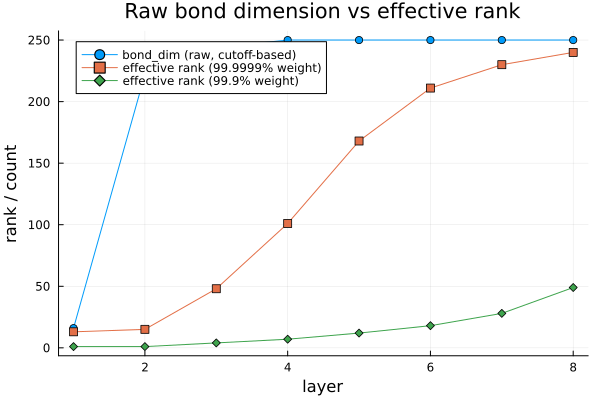

"c:\\Users\\Benjamin\\Desktop\\dmpf_dissipation-1\\oqs_generalization\\Fii_rank_comparison.png"

In [3]:
using Plots

# --- Plot 1: spectrum decay at each layer, normalized to the largest singular value ---
plt = plot(xlabel="singular value index", ylabel="log10(sᵢ / s₁)",
           title="F_ii operator-Schmidt spectrum by layer", legend=:topright)

for (idx, layer) in enumerate(result.layer)
    spec = result.spectrum[idx]
    normalized = spec ./ spec[1]
    plot!(plt, 1:length(spec), log10.(normalized .+ 1e-300),  # +eps guards log10(0)
          label="layer $layer", marker=:circle, markersize=2)
end
display(plt)
savefig(plt, "Fii_spectrum_by_layer.png")

# --- Plot 2: just the final (worst-case, layer k) spectrum on its own, larger ---
final_spec = result.spectrum[end]
plt2 = plot(1:length(final_spec), log10.(final_spec ./ final_spec[1] .+ 1e-300),
            xlabel="singular value index", ylabel="log10(sᵢ / s₁)",
            title="F_ii spectrum at final layer (k=$k)", legend=false,
            marker=:circle, markersize=3)
display(plt2)
savefig(plt2, "Fii_spectrum_final_layer.png")

# --- Plot 3: bond_dim (raw count) vs effective_rank (weight-based) side by side ---
eff_ranks = [effective_rank(s; weight_fraction=1 - 1e-6) for s in result.spectrum]
eff_ranks_loose = [effective_rank(s; weight_fraction=1 - 1e-3) for s in result.spectrum]

plt3 = plot(result.layer, result.bond_dim, label="bond_dim (raw, cutoff-based)",
            marker=:circle, xlabel="layer", ylabel="rank / count",
            title="Raw bond dimension vs effective rank", legend=:topleft)
plot!(plt3, result.layer, eff_ranks, label="effective rank (99.9999% weight)", marker=:square)
plot!(plt3, result.layer, eff_ranks_loose, label="effective rank (99.9% weight)", marker=:diamond)
display(plt3)
savefig(plt3, "Fii_rank_comparison.png")

In [ ]:
# Reads sweep_results/sweep.csv (or a path passed as ARGS[1]) and produces the
# three diagnostic plots: Gram-matrix distance, DMPF error, and coefficients.
#
# Usage:  julia plot_sweep.jl [path/to/sweep.csv]
#
# Deps: CSV, DataFrames, Plots  (add once with:
#   using Pkg; Pkg.add(["CSV","DataFrames","Plots"]) )

In [2]:
using CSV, DataFrames, Plots
 
csv_path = length(ARGS) >= 1 ? ARGS[1] : "../results/sweep.csv"
df = CSV.read(csv_path, DataFrame)

# parse the quoted, semicolon-separated coeffs field into vectors
coeff_vecs = [parse.(Float64, split(strip(s, '"'), ';')) for s in string.(df.coeffs)]
ncoeff = length(coeff_vecs[1])
ks = [3, 8]   # label coefficients by the k values they correspond to
 
maxdims = df.maxdim

4-element Vector{Int64}:
  16
  32
  64
 128

In [3]:
# --- Plot 1: Gram-matrix distance from reference vs maxdim (log y) ---
plt1 = plot(maxdims, df.M_dist,
            xlabel="maxdim", ylabel="||M - M_ref||_F", yscale=:log10,
            title="Gram matrix distance from reference",
            marker=:circle, legend=false)
savefig(plt1, "sweep_M_distance.png")

"c:\\Users\\Benjamin\\Desktop\\dmpf_dissipation-1\\oqs_generalization\\sweep_M_distance.png"

In [4]:
# --- Plot 2: DMPF error vs maxdim ---
# NOTE: E_mpf is a squared Frobenius norm and should be >= 0. Several values
# here are slightly negative -- a sign the reference precision (maxdim=256,
# k_ref=50) is at its resolution floor for an error this small. We plot the
# raw values on a LINEAR axis (log would drop the negatives silently) and mark
# zero, so the artifact is visible rather than hidden.
plt2 = plot(maxdims, df.E_mpf,
            xlabel="maxdim", ylabel="E_mpf",
            title="DMPF error vs maxdim (linear axis)",
            marker=:circle, legend=false)
hline!(plt2, [0.0], linestyle=:dash, color=:gray)
savefig(plt2, "sweep_E_mpf.png")
 
# Optional companion: |E_mpf| on a log axis, to see the magnitude trend
plt2b = plot(maxdims, abs.(df.E_mpf),
             xlabel="maxdim", ylabel="|E_mpf|", yscale=:log10,
             title="|DMPF error| vs maxdim (magnitude)",
             marker=:square, legend=false)
savefig(plt2b, "sweep_E_mpf_abs.png")

"c:\\Users\\Benjamin\\Desktop\\dmpf_dissipation-1\\oqs_generalization\\sweep_E_mpf_abs.png"

In [5]:
# --- Plot 3: coefficient stability vs maxdim ---
plt3 = plot(xlabel="maxdim", ylabel="coefficient value",
            title="DMPF coefficients vs maxdim", legend=:right)
for j in 1:ncoeff
    vals = [cv[j] for cv in coeff_vecs]
    plot!(plt3, maxdims, vals, label="c[$j] (k=$(ks[j]))", marker=:circle)
end
savefig(plt3, "sweep_coefficients.png")
 
println("wrote: sweep_M_distance.png, sweep_E_mpf.png, sweep_E_mpf_abs.png, sweep_coefficients.png")
 

wrote: sweep_M_distance.png, sweep_E_mpf.png, sweep_E_mpf_abs.png, sweep_coefficients.png


7/17: For sanity checks, we are checking down below the spectrum of $F$ in the closed-system case after two different computations: (i) full forward propagation and full backwards propagation using plain multiplication and (ii) clock-synchronizing the left and right multiplications with the middle-out contraction algorithm. We would expect the bond dimension of F to remain large in the case (i) and very  small in (ii).


In [7]:
# Plots the closed-system MOC vs PLAIN comparison from moc_results/*.csv.
#
# Usage: julia plot_moc_compare.jl [moc_results_dir]
# Deps: CSV, DataFrames, Plots

using CSV, DataFrames, Plots

# ---- Plot 1: bond dimension per step, both methods ----
bd = CSV.read("../results/bond_dim_compare.csv", DataFrame)
moc   = bd[bd.method .== "moc",   :]
plain = bd[bd.method .== "plain", :]

plt1 = plot(xlabel="contraction step", ylabel="middle bond dimension",
            title="Bond dimension growth: MOC vs plain (closed system)",
            legend=:right, marker=:circle)
plot!(plt1, plain.step, plain.bond_dim, label="plain (fwd 1-8, bwd 9-16)", marker=:circle, lw=2)
plot!(plt1, moc.step,   moc.bond_dim,   label="MOC (per sync)", marker=:square, lw=2)
# mark the forward/backward boundary of the plain run
vline!(plt1, [8.5], linestyle=:dash, color=:gray, label="plain: fwd|bwd")
savefig(plt1, "moc_bond_dim_compare.png")

# ---- Plot 2: operator-Schmidt spectrum by step, PLAIN (log ratio) ----
# (MOC spectra are all trivial length-1, so only PLAIN is interesting to plot.)
sp = CSV.read("../results/spectra_compare.csv", DataFrame)
sp_plain = sp[sp.method .== "plain", :]

plt2 = plot(xlabel="singular value index", ylabel="log10(s_i / s_1)",
            title="F_ii operator-Schmidt spectrum by step (plain, closed system)",
            legend=:topright)
for s in sort(unique(sp_plain.step))
    sub = sp_plain[sp_plain.step .== s, :]
    lbl = s <= 8 ? "fwd $s" : "bwd $(s-8)"
    plot!(plt2, sub.index, sub.log10_ratio, label=lbl, marker=:circle, ms=2, lw=1)
end
savefig(plt2, "moc_plain_spectrum_by_step.png")

# ---- Plot 3: log-scale bond dim, to see MOC=1 vs plain clearly ----
plt3 = plot(xlabel="contraction step", ylabel="middle bond dimension (log)",
            yscale=:log10,
            title="Bond dimension (log scale): MOC stays at 1",
            legend=:right)
plot!(plt3, plain.step, plain.bond_dim, label="plain", marker=:circle, lw=2)
plot!(plt3, moc.step,   moc.bond_dim,   label="MOC",   marker=:square, lw=2)
savefig(plt3, "moc_bond_dim_log.png")

println("wrote: moc_bond_dim_compare.png, moc_plain_spectrum_by_step.png, moc_bond_dim_log.png")


wrote: moc_bond_dim_compare.png, moc_plain_spectrum_by_step.png, moc_bond_dim_log.png


Now the same analysis but turning on dissipation, with a dissipative rate of 0.05

In [8]:
# Plots the closed-system MOC vs PLAIN comparison from moc_results/*.csv.
#
# Usage: julia plot_moc_compare.jl [moc_results_dir]
# Deps: CSV, DataFrames, Plots

using CSV, DataFrames, Plots

# ---- Plot 1: bond dimension per step, both methods ----
bd = CSV.read("../results/bond_dim_compare_open.csv", DataFrame)
moc   = bd[bd.method .== "moc",   :]
plain = bd[bd.method .== "plain", :]

plt1 = plot(xlabel="contraction step", ylabel="middle bond dimension",
            title="Bond dimension growth: MOC vs plain (closed system)",
            legend=:right, marker=:circle)
plot!(plt1, plain.step, plain.bond_dim, label="plain (fwd 1-8, bwd 9-16)", marker=:circle, lw=2)
plot!(plt1, moc.step,   moc.bond_dim,   label="MOC (per sync)", marker=:square, lw=2)
# mark the forward/backward boundary of the plain run
vline!(plt1, [8.5], linestyle=:dash, color=:gray, label="plain: fwd|bwd")
savefig(plt1, "moc_bond_dim_compare_open.png")

# ---- Plot 2: operator-Schmidt spectrum by step, PLAIN (log ratio) ----
# (MOC spectra are all trivial length-1, so only PLAIN is interesting to plot.)
sp = CSV.read("../results/spectra_compare_open.csv", DataFrame)
sp_plain = sp[sp.method .== "plain", :]

plt2 = plot(xlabel="singular value index", ylabel="log10(s_i / s_1)",
            title="F_ii operator-Schmidt spectrum by step (plain, closed system)",
            legend=:topright)
for s in sort(unique(sp_plain.step))
    sub = sp_plain[sp_plain.step .== s, :]
    lbl = s <= 8 ? "fwd $s" : "bwd $(s-8)"
    plot!(plt2, sub.index, sub.log10_ratio, label=lbl, marker=:circle, ms=2, lw=1)
end
savefig(plt2, "moc_plain_spectrum_by_step_open.png")

# ---- Plot 3: log-scale bond dim, to see MOC=1 vs plain clearly ----
plt3 = plot(xlabel="contraction step", ylabel="middle bond dimension (log)",
            yscale=:log10,
            title="Bond dimension (log scale): MOC stays at 1",
            legend=:right)
plot!(plt3, plain.step, plain.bond_dim, label="plain", marker=:circle, lw=2)
plot!(plt3, moc.step,   moc.bond_dim,   label="MOC",   marker=:square, lw=2)
savefig(plt3, "moc_bond_dim_log_open.png")

println("wrote: moc_bond_dim_compare_open.png, moc_plain_spectrum_by_step_open.png, moc_bond_dim_log_open.png")

wrote: moc_bond_dim_compare_open.png, moc_plain_spectrum_by_step_open.png, moc_bond_dim_log_open.png
